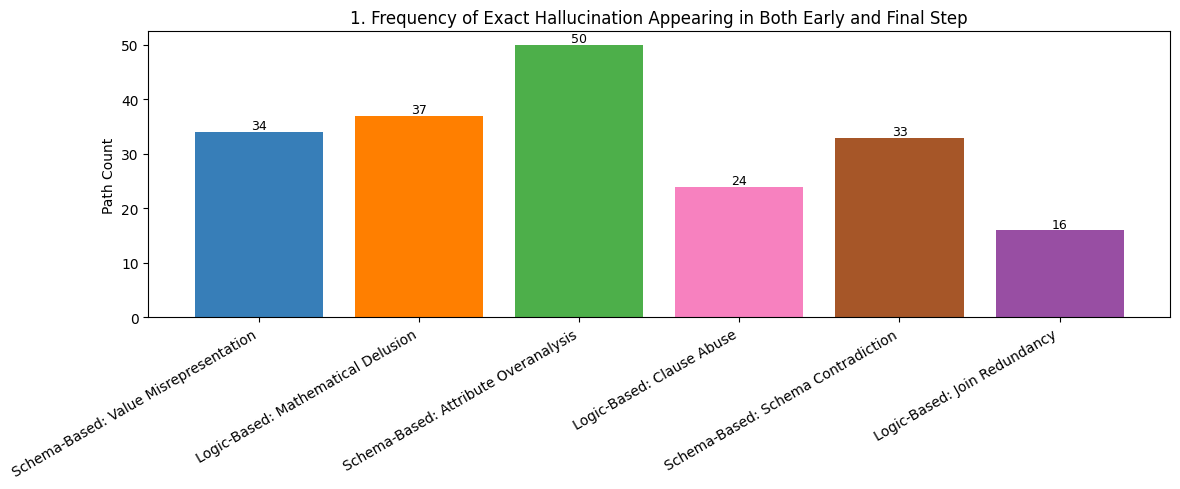

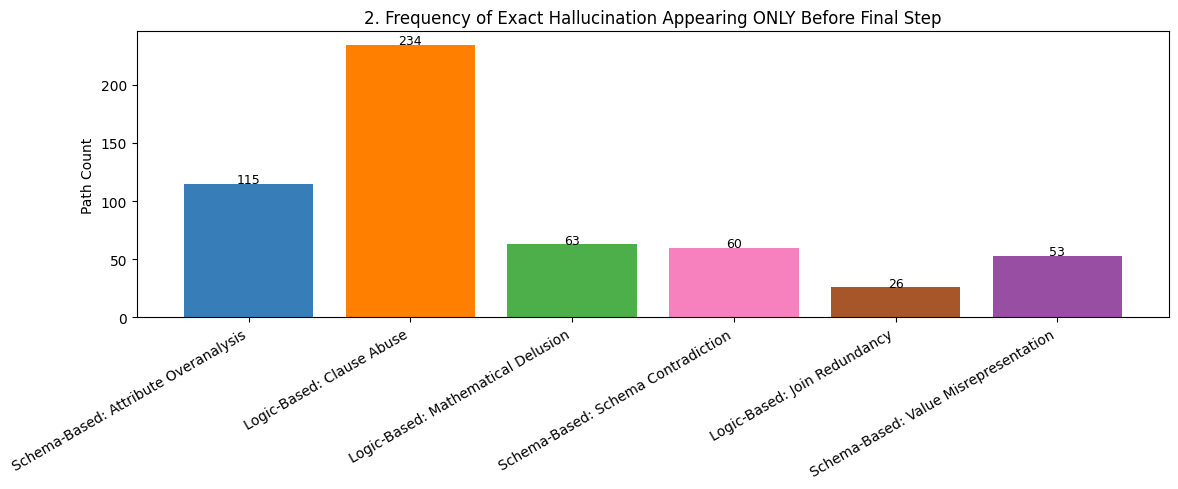

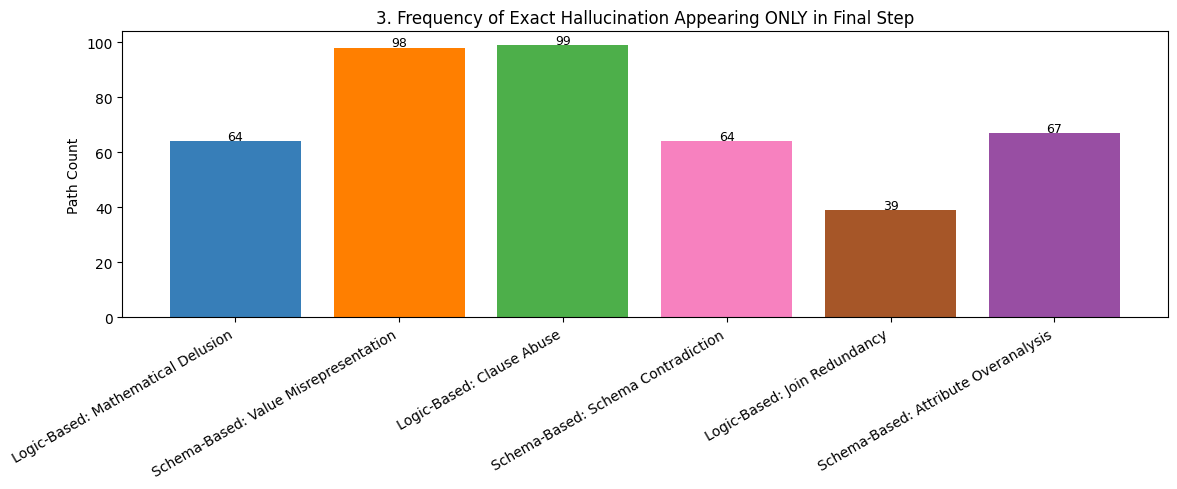

In [7]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_3_5.json', 'r') as f:
    data = json.load(f)

# Hallucination types grouped by h[0]
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))


# -------------------- 1. Count: Early AND Final --------------------

both_counts = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev = defaultdict(set)
    final_step = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev[h[0]].add(h)

    for htype in hallucination_types:
        if all_prev[htype] & final_step[htype]:
            both_counts[htype] += 1

plt.figure(figsize=(12, 5))
bars = plt.bar(
    both_counts.keys(),
    both_counts.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("Path Count")
plt.title("1. Frequency of Exact Hallucination Appearing in Both Early and Final Step")
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(int(yval)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 2. Count: Early Only (Not Final) --------------------

early_only_counts = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev = defaultdict(set)
    final_step = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev[h[0]].add(h)

    for htype in hallucination_types:
        if all_prev[htype] and not (all_prev[htype] & final_step[htype]):
            early_only_counts[htype] += 1

plt.figure(figsize=(12, 5))
bars = plt.bar(
    early_only_counts.keys(),
    early_only_counts.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("Path Count")
plt.title("2. Frequency of Exact Hallucination Appearing ONLY Before Final Step")
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(int(yval)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 3. Count: Final Only (Not Seen Earlier) --------------------

final_only_counts = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev = defaultdict(set)
    final_step = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev[h[0]].add(h)

    for htype in hallucination_types:
        if final_step[htype] and not (final_step[htype] & all_prev[htype]):
            final_only_counts[htype] += 1

plt.figure(figsize=(12, 5))
bars = plt.bar(
    final_only_counts.keys(),
    final_only_counts.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("Path Count")
plt.title("3. Frequency of Exact Hallucination Appearing ONLY in Final Step")
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(int(yval)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


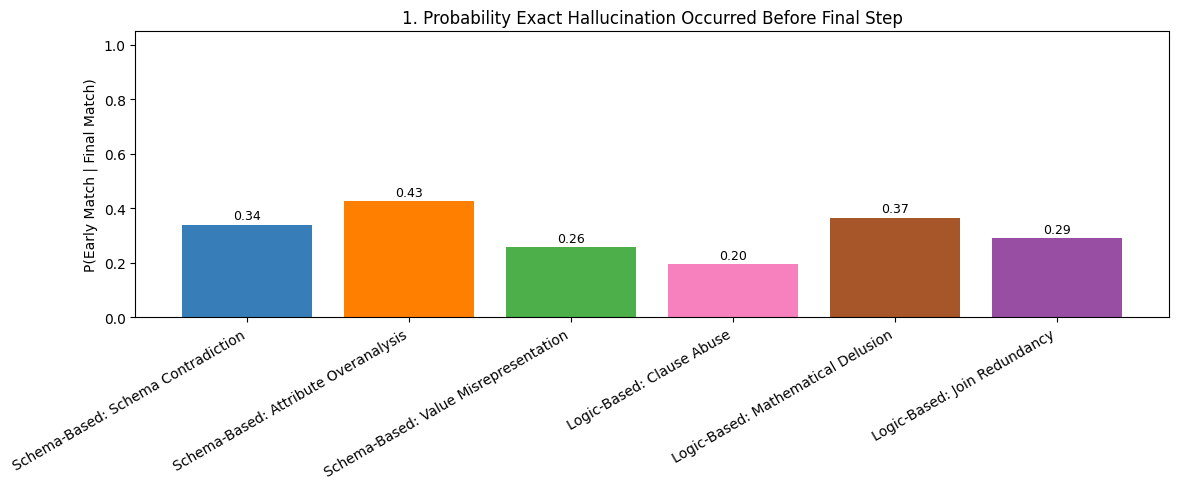

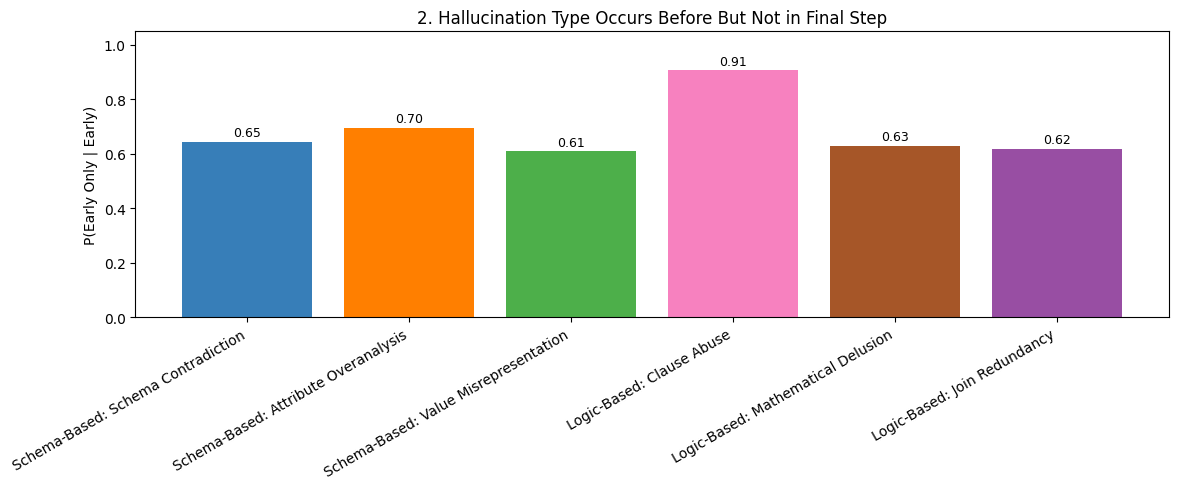

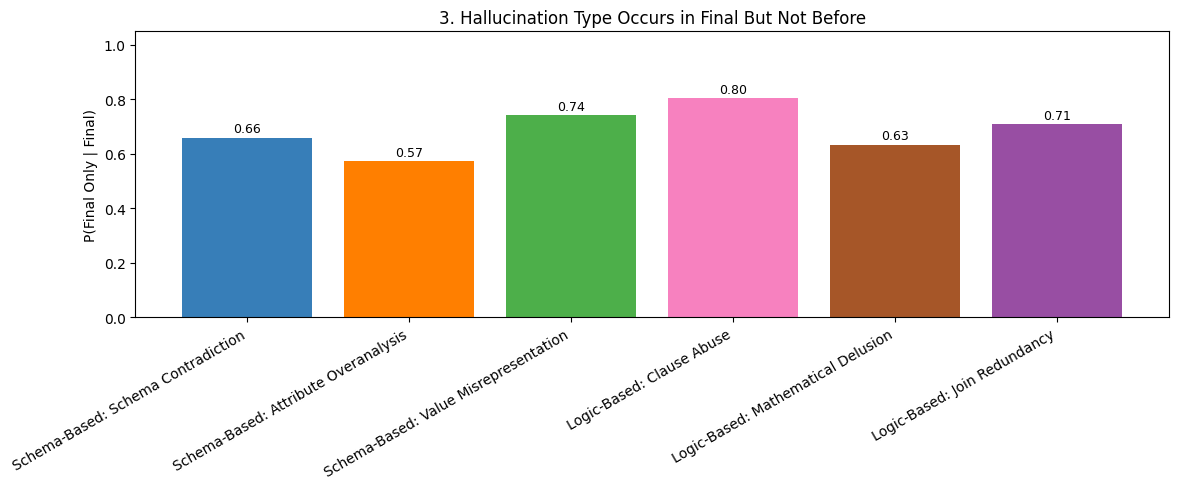

In [8]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_3_5.json', 'r') as f:
    data = json.load(f)

# Define top-level hallucination types (grouped by h[0])
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

# -------------------- 1. P(Occurred Before | Occurred in Final) --------------------

paths_with_final_htype = defaultdict(int)
paths_with_htype_before_final = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                htype = h[0]
                final_step_halls_by_type[htype].add(h)
        else:
            for h in halluc_set:
                htype = h[0]
                all_prev_halls_by_type[htype].add(h)

    for htype in hallucination_types:
        prev_set = all_prev_halls_by_type[htype]
        final_set = final_step_halls_by_type[htype]

        if final_set:
            paths_with_final_htype[htype] += 1
            if prev_set & final_set:
                paths_with_htype_before_final[htype] += 1

fractions_1 = {
    htype: paths_with_htype_before_final[htype] / paths_with_final_htype[htype]
    if paths_with_final_htype[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_1.keys(),
    fractions_1.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Early Match | Final Match)")
plt.title("1. Probability Exact Hallucination Occurred Before Final Step")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 2. P(Early But Not Final) --------------------

paths_with_type_not_final = defaultdict(int)
paths_with_type_before_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step_halls_by_type[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev_halls_by_type[h[0]].add(h)

    for htype in hallucination_types:
        prev = all_prev_halls_by_type[htype]
        final = final_step_halls_by_type[htype]

        if prev and not (prev & final):
            paths_with_type_before_only[htype] += 1
        if prev:
            paths_with_type_not_final[htype] += 1

fractions_2 = {
    htype: paths_with_type_before_only[htype] / paths_with_type_not_final[htype]
    if paths_with_type_not_final[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_2.keys(),
    fractions_2.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Early Only | Early)")
plt.title("2. Hallucination Type Occurs Before But Not in Final Step")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# -------------------- 3. P(Final Only | Final) --------------------

paths_with_final = defaultdict(int)
paths_with_final_only = defaultdict(int)

for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                final_step_halls_by_type[h[0]].add(h)
        else:
            for h in halluc_set:
                all_prev_halls_by_type[h[0]].add(h)

    for htype in hallucination_types:
        final = final_step_halls_by_type[htype]
        prev = all_prev_halls_by_type[htype]

        if final:
            paths_with_final[htype] += 1
            if not (final & prev):
                paths_with_final_only[htype] += 1

fractions_3 = {
    htype: paths_with_final_only[htype] / paths_with_final[htype]
    if paths_with_final[htype] > 0 else 0
    for htype in hallucination_types
}

plt.figure(figsize=(12, 5))
bars = plt.bar(
    fractions_3.keys(),
    fractions_3.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Only | Final)")
plt.title("3. Hallucination Type Occurs in Final But Not Before")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
